In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit, lax,vmap
from jax import config
from jax.scipy.linalg import expm
from numpy.linalg import eigh
config.update("jax_enable_x64", True)
config.update("jax_platform_name","cpu")

# Non-Hermitian Parametric Matrix Model (PMM) for Open Quantum Systems

This notebook implements an **Effective Latent Space Emulator** to model the dynamics of a spin system coupled to a bosonic bath (the Spin-Boson model). Instead of simulating a massive Hilbert space using tensor products, we use a **Direct Sum** approach to build a compact, learnable non-Hermitian Hamiltonian.

---

### 1. The Effective Hamiltonian ($H_{\text{eff}}$)

We represent the total system using a block-matrix structure of dimension $(n + m) \times (n + m)$, where $n$ is the system dimension (e.g., $n=2$ for a qubit) and $m$ is the hidden "bath" dimension.

$$H_{\text{eff}}(c) = \begin{pmatrix} M(c) & C \\ 0 & B \end{pmatrix}$$

* **System Block $M(c)$**: A Hermitian matrix representing the internal spin dynamics, parameterized by control variable $c$:
  $$M(c) = A_0 + \sum_{i=1}^{L} c_i A_i$$
* **Bath Block $B$**: A general non-Hermitian matrix $B \in \mathbb{C}^{m \times m}$ representing the environment's decay and internal degrees of freedom.
* **Coupling Block $C$**: A learnable complex matrix $C \in \mathbb{C}^{n \times m}$ that allows information/energy to leak from the system into the bath.
* **The Zero Block**: By setting the bottom-left block to $\mathbf{0}_{m \times n}$, we enforce a unidirectional flow of information (from bath to system/leakage), which emulates Markovian-like dissipation.



---

### 2. Time Evolution and Subspace Projection

The latent state $|\Phi(t)\rangle \in \mathbb{C}^{n+m}$ evolves via the matrix exponential (Schrödinger-like evolution):

$$|\Phi(t)\rangle = \exp(-i H_{\text{eff}} t) |\Phi(0)\rangle$$

Since $H_{\text{eff}}$ is **non-Hermitian**, the norm of $|\Phi(t)\rangle$ is not conserved. To find the physical Bloch vector components, we "slice" the first $n$ elements (the system subspace) and re-normalize the state:

$$|\psi_s(t)\rangle = \frac{\mathcal{P}_n |\Phi(t)\rangle}{\| \mathcal{P}_n |\Phi(t)\rangle \|}$$

where $\mathcal{P}_n$ is the projection operator onto the first $n$ dimensions.

In this case we just take the first n components of $|\Phi(t)\rangle$, i.e. $\psi(t) = |\Phi(t)[:n]\rangle/||\Phi(t)[:n]\rangle||$ in python.

---

### 3. Observables and Learning

We calculate the expectation values for the Bloch components $r_k(t)$ (where $k \in \{x, y, z\}$) using learnable observation matrices $O_k$:

$$r_k(t) = Tr(\rho O_k) =\langle \psi_s(t) | O_k | \psi_s(t) \rangle$$

The model learns the parameters $\Theta = \{A_i, B, C, O_k, \Phi(0)\}$ by minimizing the Mean Squared Error (MSE) between the predicted $r_k(t)$ and the exact Spin-Boson training data:

$$\mathcal{L}(\Theta) = \frac{1}{N_t} \sum_{t} \sum_{k} (r_k^{\text{pred}}(t) - r_k^{\text{true}}(t))^2$$



---

### Optimization Challenges

In systems where $r_z \approx 1$ and $r_x, r_y \approx 0$:
1. **Numerical Stability**: Normalizing a vector that is nearly zero in its transverse components is sensitive to floating-point noise, often resulting in small, artificial oscillations.
2. **Stationary States**: The model must learn to suppress off-diagonal terms in $M(c)$ and the coupling $C$ with extreme precision to prevent unwanted precession.

In [2]:
class model(object):
    def __init__(self,
                 n,
                 m,
                 X_train,
                 y_train,
                 k,
                 l,
                 type=True,
                 X_val=None,
                 y_val=None,
                 param=None,
                 epochs = np.inf,
                 learning_rate =0.01,
                 print_every = 100,
                 verbose: bool = True):

        """
        Initializes the Parameterized Matrix Model (PMM).

        Parameters:
            n (int): The size of the PMM matrix (n x n).
            X_train (jnp.array): Training input features (X data).
            y_train (jnp.array): Training target values (y data, typically k eigenvalues).
            k (int): The number of eigenvalues (initial states) to be predicted.
            l (int): The number of observable matrices (M_1, ..., M_l) in the PMM, where M = M_0 + sum(x_i * M_i).
            type (bool, optional): If True, uses complex parameters (jnp.complex128). If False, uses real parameters (jnp.float64). Defaults to True.
            X_val (jnp.array, optional): Validation input features. Defaults to None.
            y_val (jnp.array, optional): Validation target values. Defaults to None.
            param (jnp.array, optional): Saved initial parameters (theta) to use instead of generating new ones. Defaults to None.
            epochs (int, optional): The maximum number of iterations for gradient descent (GD). Defaults to infinity (np.inf).
            learning_rate (float, optional): The learning rate for the ADAM optimizer. Defaults to 0.01.
            print_every (int, optional): Number of GD iterations before printing the loss. Defaults to 100.
            verbose (bool, optional): Enable or disable printing the loss function during training. Defaults to True.
        """

        self.n = n #size of system
        self.m = m #size of bath
        self.y_train = y_train # y train set
        self.X_train = X_train #x train set
        self.k = k #number of observables
        self.l= l #number of M matrices
        self.y_val = y_val #y validation set
        self.X_val = X_val #x validatoin set
        self.params = param #to used saved parameters
        self.epochs = epochs #number of iteration for gd
        self.learning_rate = learning_rate #learning rate
        self.print_every = print_every #how many iterations of gd before pringing loss
        self.verbose = verbose #enable for printing loss function
        self.type = type #complex or real
        if self.type == True:
            self.dtype = jnp.complex128
        elif self.type == False:
            self.dtype = jnp.float64

    ####################################
    # 1. PARAMETER INITIALIZATION
    ####################################
    def get_param(self):
      """
      Calculates the total number of required weights and initializes
      them as a flat vector (theta).
      """
      # Total count:
      # A (system dynamics) + B (bath) + C (coupling)
      # + O (measurement operators) + phi (initial state h0)
      num_params = ((self.l+1)*self.n*self.n +  # A: (l+1) matrices of size n x n
                    self.m*self.m +             # B: m x m bath matrix
                    self.n*self.m +             # C: n x m coupling matrix
                    self.k*self.n*self.n +      # O: k measurement matrices
                    self.n + self.m)            # phi: initial state vector of length n + m

      # Initialize with small random values (0.01 scaling to prevent gradient explosion)
      if self.type == True: # Complex initialization
          theta = 0.01*(np.random.randn(num_params) + 1j*np.random.randn(num_params))
      elif self.type == False: # Real-only initialization
          theta = 0.01*(np.random.randn(num_params))
      return theta

    ####################################
    # 2. PARAMETER UNPACKING & SYMMETRIZATION
    ####################################
    def split_params(self, theta):
      """
      Reshapes the flat theta vector back into the physical matrices
      and enforces Hermiticity on the system subspace A.
      """
      theta = jnp.asarray(theta)

      # Define the "slices" for each block based on dimensions
      A_param = (self.l+1)*self.n*self.n
      B_param = self.m*self.m
      C_param = self.n*self.m
      O_param = self.k*self.n*self.n
      phi_param = self.n + self.m

      current_idx = 0

      # --- System Hamiltonian A (Hermitian Subspace) ---
      # Unpacks l+1 matrices. Note: l+1 allows for time-dependent or parametric scaling.
      A = jnp.reshape(theta[current_idx:current_idx+A_param], (self.l+1, self.n, self.n))
      # Enforce Hermiticity: A = (A + A_dagger) / 2
      A = (A + A.conj().transpose(0, 2, 1)) / 2
      current_idx += A_param

      # --- Bath Matrix B (Non-Hermitian) ---
      B = jnp.reshape(theta[current_idx:current_idx+B_param], (self.m, self.m))
      current_idx += B_param

      # --- Interaction Matrix C (System-Bath Coupling) ---
      C = jnp.reshape(theta[current_idx:current_idx+C_param], (self.n, self.m))
      current_idx += C_param

      # --- Observables O (Measurement Operators) ---
      # Typically k=3 for sigma_x, sigma_y, sigma_z
      O = jnp.reshape(theta[current_idx:current_idx+O_param], (self.k, self.n, self.n))
      O = (O + O.conj().transpose(0, 2, 1)) / 2
      current_idx += O_param

      # --- Initial State phi (h0) ---
      # Total length is n + m
      phi = theta[current_idx:current_idx+phi_param]
      phi = phi / jnp.linalg.norm(phi)

      return A, B, C, O, phi


    ####################################
    # 3. PMM Model
    ####################################
    def update(self, theta, X_data):
      """
      Computes the non-unitary time evolution of a system coupled to a latent bath
      using a Parametric Matrix Model (PMM).

      Args:
          theta (array): Flat vector of learnable parameters (A, B, C, O, phi).
          X_data (array): Input features where X[:, 0] are controls 'c'
                         and X[:, 1] are time points 't'.

      Returns:
          y_pred (array): Predicted Bloch trajectories of shape (Nt, k).

      --- MATH AND LOGIC ---

      1. Hamiltonian Construction:
      The model constructs a global effective Hamiltonian (H_eff) in a
      latent space of dimension D = n + m. The system part (M) is a linear
      combination of Hermitian matrices A_i scaled by control parameters (c):

      M(c) = A_0 + sum( c_i * A_i )

      The full non-Hermitian Hamiltonian is assembled as a block matrix:

      H_eff = [ M(c)   C ]
              [  0     B ]

      where C is the system-bath coupling and B represents the bath dynamics.

      2. State Evolution:
      The latent state |phi(t)> (dimension n + m) evolves via the matrix
      exponential (propagator):

      |phi(t)> = exp(-i * H_eff * t) * |phi(0)>

      Because H_eff is non-Hermitian, the norm of |phi(t)> is not conserved,
      simulating energy/information leakage into the bath.

      3. Subspace Projection and Observables:
      The physical system state |psi_s(t)> is extracted by slicing the
      first 'n' components and normalizing to ensure a valid probability:

      |psi_s(t)> = |phi(t)>[0:n] / || |phi(t)>[0:n] ||

      The predicted coordinates (e.g., Bloch vectors) are the expectation
      values of learnable operators O_k:

      y_k(t) = <psi_s(t) | O_k | psi_s(t)>


      """
      # X_data: [control_c, time_t]
      c = X_data[:,0]
      t = X_data[:,1]
      # 1. Unpack the parameters from the flat theta vector
      A,B,C,O,phi = self.split_params(theta)
      # 2. Build Spin Hamiltonian M = A_0 + sum(c_i * A_i)
      M = A[0]+ jnp.einsum('i,ijk->jk',c,A[1:])
      # 3. Build the full Non-Hermitian Hamiltonian H
      zero_block = jnp.zeros((self.m,self.n),dtype=A.dtype)
      H = jnp.block([
                    [M,C],
                    [zero_block,B]
                    ])
      # 4. Define the single-step evolution and measurement
      def pmm_time_ev(t_val, H_eff, O_ops, phi0):
        # Evolution in the full (n+m) latent space
        phi_t = expm(-1j*H_eff * t_val)@phi0 #idk if one can do it in eigenspace, since it's not hermitian, and jax sucks for autograd non-hermitian

        # Slice the first 'n' elements (the system subspace)
        psi_s = phi_t[:self.n]

        # Normalize the sliced state to keep it on/inside the Bloch sphere
        psi_s_norm = psi_s / jnp.linalg.norm(psi_s)

        # Calculate Tr(rho * O_i) for each of the k operators
        # rho = |psi><psi|, so Tr(rho * O) = <psi|O|psi>
        def measure(op):
          return jnp.real(jnp.vdot(psi_s_norm, op @ psi_s_norm))
        return jax.vmap(measure)(O_ops)

      # 5. Vectorize over the time axis 't'
      # in_axes: (0, None, None, None) means vectorize t, but keep H, O, phi constant
      y_pred = jax.vmap(pmm_time_ev, in_axes=(0, None, None, None))(t, H, O, phi)
      return y_pred # Shape: (Nt, k) -> (times, components)


    def Cost(self,y_true,y_pred):
      """
      Calculates the mean squared error (MSE) between true and predicted values.

      Cost = mean(|y_true - y_pred|^2)

      Parameters:
          y_true (jnp.array): The true target values.
          y_pred (jnp.array): The predicted values.

      Returns:
          float: The real-valued mean squared loss.
      """
      cost = jnp.mean((abs(y_true - y_pred)**2))
      return cost.real


    def Loss(self,theta,X_data,y_true):
      """
      Calculates the full loss function: first computes predictions, then the cost.

      Parameters:
          theta (jnp.array): Model parameters.
          X_data (jnp.array): Input features.
          y_true (jnp.array): True target values.

      Returns:
          float: The real-valued loss (Cost) for the given parameters and data.
      """
      y_pred = self.update(theta,X_data)
      return self.Cost(y_true,y_pred)


    def dLossdx(self,theta,X_data,y_true):
      """
      Computes the gradient of the Loss function with respect to the parameters (theta)
      using JAX's automatic differentiation.

      Parameters:
          theta (jnp.array): Model parameters.
          X_data (jnp.array): Input features.
          y_true (jnp.array): True target values.

      Returns:
          jnp.array: The gradient of the loss function with respect to theta.
      """
      return grad(self.Loss)(theta,X_data,y_true)

    def ADAM(self,g,i,m,v):
      """
      Performs one step of the ADAM (Adaptive Moment Estimation) optimization algorithm.

      Parameters:
          g (jnp.array): The current gradient of the loss function.
          i (int): The current iteration number (0-indexed).
          m (jnp.array): The previous biased first moment vector (m_{t-1}).
          v (jnp.array): The previous biased second raw moment vector (v_{t-1}).

      Returns:
          tuple: (delta_theta, m_new, v_new) where:
                  - delta_theta (jnp.array): The parameter update direction.
                  - m_new (jnp.array): The updated first moment vector (m_t).
                  - v_new (jnp.array): The updated second moment vector (v_t).
      """
      b1=0.9
      b2=0.999
      eps=1e-8
      # update biased first moment estimate
      m_new = b1 * m + (1 - b1) * g
      # update biased second raw moment estimate
      v_new = b2 * v + (1 - b2) * (g*g.conj())
      # compute bias-corrected first moment estimate
      mhat = m_new / (1 - b1 ** (i + 1))
      # compute bias-corrected second raw moment estimate
      vhat = v_new / (1 - b2 ** (i + 1))
      delta_theta = mhat / (jnp.sqrt(vhat) + eps)
      return delta_theta, m_new, v_new


    def train(self):
      """
      Executes the training process using gradient descent with the ADAM optimizer.

      The model iterates through a specified number of epochs, computes the gradient
      of the loss, updates parameters using ADAM, and monitors the loss. It saves
      the parameters that result in the best validation loss (if X_val is provided)
      or the best training loss otherwise.

      Returns:
          jnp.array: The best set of parameters (theta) found during training.
      """
      theta = jnp.array(self.get_param() if self.params is None else self.params,dtype=self.dtype)

      self.best_param = None
      best_loss = np.inf
      best_val_loss = np.inf

      X_train = self.X_train
      y_train = self.y_train
      X_val = self.X_val
      y_val = self.y_val

      # JAX Optimization: jit compiles the core mathematical operations (gradient,
      # loss, PMM matrix construction, and eigenvalue computation) into a single,
      # optimized XLA kernel for maximum speed.
      # (dLossdx -> Loss -> update -> split_params) that uses JAX arrays.
      jgrad = jit(lambda theta,X_train,y_train: self.dLossdx(theta,X_train,y_train))
      jLoss = jit(lambda theta,X_train,y_train: self.Loss(theta,X_train,y_train))
      jADAM = jit(lambda g_in, i_in, m_in, v_in: self.ADAM(g_in, i_in, m_in, v_in))

      #ADAM parameters
      m = np.zeros(theta.shape, dtype=theta.dtype)
      v = np.zeros(theta.shape, dtype=theta.dtype)
      i = 0
      num_samples = X_train.shape[0]
      while i < self.epochs:
          #calculate gradient
          g = jgrad(theta,X_train,y_train)
          delta_theta, m, v = jADAM(g.conj(),i,m,v)
          theta = theta - self.learning_rate*delta_theta

          #print loss
          loss = jLoss(theta,X_train,y_train)

          ################################################
          # for verbose printing
          ################################################
          if self.verbose and i % self.print_every == 0:
              # ANSI escape codes for colors and bold text
              COLOR_CYAN = "\033[96m"
              COLOR_GREEN = "\033[92m"
              COLOR_YELLOW = "\033[93m"
              COLOR_RED = "\033[91m"
              COLOR_RESET = "\033[0m" # Resets all formatting

              # Determine color based on loss trend (conceptual, you'd need history for this)
              # For simplicity, let's just make the losses stand out.

              # Header Line
              print(f"{COLOR_CYAN}═════════════════════════════════════════════════{COLOR_RESET}")

              # Epoch line
              print(f"  {COLOR_CYAN}🌌 Epoch {i:<8}{COLOR_RESET} | {COLOR_GREEN}Training Loss: {loss:.2e}{COLOR_RESET} |", end="")

              # Validation Loss line (if applicable)
              if X_val is not None:
                  val_loss = jLoss(theta, X_val, y_val)
                  print(f" {COLOR_YELLOW}Validation Loss: {val_loss:.2e}{COLOR_RESET} |", end="")

              print(f"\n{COLOR_CYAN}═════════════════════════════════════════════════{COLOR_RESET}")
          ################################################

          i += 1

          if X_val is not None:
              val_loss = jLoss(theta,X_val,y_val)
              if val_loss < best_val_loss:
                  self.best_param = theta
                  best_val_loss = val_loss
          elif loss < best_loss:
              self.best_param = theta
              best_loss = loss

      if X_val is not None:
          return self.best_param
      else:
          return self.best_param

    def predict(self,theta,X_test):
      """
      Generates predictions (eigenvalues) on new test data using a trained set of parameters.

      Parameters:
          theta (jnp.array): The trained parameters (often the best_param returned by `train`).
          X_test (jnp.array): The input features (X data) for prediction.

      Returns:
          jnp.array: The predicted values (first k eigenvalues) for X_test.
      """
      return self.update(theta,X_test)


# Time Evolution of Spin + Bosonic Bath

In [3]:

# ============================================================
# 1. Bosonic and spin operators
# ============================================================

def boson_operators(Mb: int):
    """Single bosonic mode truncated to Mb Fock states."""
    a = np.zeros((Mb, Mb), dtype=np.complex128)
    for n in range(1, Mb):
        a[n - 1, n] = np.sqrt(n)
    adag = a.conj().T
    n_op = adag @ a
    I_b = np.eye(Mb, dtype=np.complex128)
    return a, adag, n_op, I_b


def su2_operators_symmetric_subspace(N: int):
    """Collective SU(2) operators in the symmetric spin subspace."""
    J = N / 2.0
    d = N + 1

    m_vals = np.arange(-J, J + 1, 1.0)

    Jz = np.diag(m_vals)
    Jp = np.zeros((d, d), dtype=np.complex128)
    Jm = np.zeros((d, d), dtype=np.complex128)

    for i, m in enumerate(m_vals):
        if i + 1 < d:
            Jp[i + 1, i] = np.sqrt(J * (J + 1) - m * (m + 1))
        if i - 1 >= 0:
            Jm[i - 1, i] = np.sqrt(J * (J + 1) - m * (m - 1))

    Jx = 0.5 * (Jp + Jm)
    Jy = -0.5j * (Jp - Jm)
    return Jx, Jy, Jz, Jp, Jm, J


# ============================================================
# 2. Spectral density and discretization
# ============================================================

def spectral_density(name: str, omega, params):
    """Return J(omega) for the given type and parameters."""
    if name.lower() == "ohmic":
        alpha = params.get("alpha", 0.1)
        omega_c = params.get("omega_c", 5.0)
        s = params.get("s", 1.0)  # s=1 ohmic, s<1 sub, s>1 super
        return alpha * (omega ** s) * np.exp(-omega / omega_c)

    elif name.lower() == "lorentz":
        alpha = params.get("alpha", 0.1)
        omega_0 = params.get("omega_0", 1.0)
        gamma = params.get("gamma", 0.5)
        return alpha * gamma ** 2 / ((omega - omega_0) ** 2 + gamma ** 2)

    else:
        raise ValueError(f"Unknown spectral density '{name}'.")


def discretize_spectral_density(Jfunc, omega_max, K, params):
    """
    Discretize J(omega) on [0, omega_max] into K bosonic modes.
    Returns mode frequencies ω_k and couplings g_k.
    """
    omega_k = np.linspace(0, omega_max, K + 1)[1:]  # skip 0

    if len(omega_k) > 1:
        diff_omega = omega_k[1] - omega_k[0]
    else:
        diff_omega = omega_max

    J_vals = Jfunc(omega_k, params)

    # relation J(ω) approx pi sum |g_k|^2 delta(omega-omega_k)
    g_k = np.sqrt(J_vals * diff_omega / np.pi)
    return omega_k, g_k


# ============================================================
# 3. Multi-mode spin–boson Hamiltonian
# ============================================================

def spin_boson_hamiltonian_multimode(
    N,
    Mb,
    eps,
    Delta,
    spectral_name,
    spec_params,
    K,
    omega_max,
):
    """
    Multi-mode spin–boson Hamiltonian:

    H = eps Jz + Delta Jx
        + sum_k [ omega_k a_k^+ a_k + Jz ( g_k (a_k + a_k^+) ) ]
    """
    Jx, Jy, Jz, Jp, Jm, J = su2_operators_symmetric_subspace(N)

    # discretize spectral density
    def Jfunc(ω, p):
        return spectral_density(spectral_name, ω, p)

    wk, gk = discretize_spectral_density(Jfunc, omega_max, K, spec_params)

    # single-mode ops
    single_ops = [boson_operators(Mb) for _ in range(K)]
    I_s = np.eye(Jz.shape[0], dtype=np.complex128)

    # build full tensor product
    I_modes = [op[3] for op in single_ops]

    def kron_all(ops):
        out = np.array([[1.0 + 0j]])
        for op in ops:
            out = np.kron(out, op)
        return out

    def embed_boson(op_list, k):
        ops = [I_modes[j] if j != k else op_list[k] for j in range(K)]
        return kron_all(ops)

    # total identity in bath space
    I_bath = kron_all(I_modes)
    dim_bath = I_bath.shape[0]

    H = np.zeros(
        ((N + 1) * dim_bath, (N + 1) * dim_bath),
        dtype=np.complex128,
    )

    # spin and bath parts
    H_spin = np.kron(eps * Jz + Delta * Jx, I_bath)
    H += H_spin

    for k in range(K):
        a, adag, n_op, I_b = single_ops[k]

        # ω_k a_k^+ a_k
        H += np.kron(I_s, wk[k] * embed_boson([n_op] * K, k))

        # Jz g_k (a_k + a_k^+)
        H += np.kron(
            Jz,
            gk[k] * (embed_boson([a] * K, k) + embed_boson([adag] * K, k)),
        )

    # Enforce Hermitian Hamiltonian.
    H = 0.5 * (H + H.conj().T)
    return H, (Jx, Jz, wk, gk)


In [4]:
# ============================================================
# 8. Exact time evolution for Spin–Boson + density matrix tools
# ============================================================

def time_evolution_spinboson(H, psi0, times):
    """
    Exact time evolution |psi(t)> = exp(-i H t) |psi0> for the spin–boson Hamiltonian.
    """
    evals, evecs = eigh(H)            # H = V diag(E) V^+
    coeffs = evecs.conj().T @ psi0    # expansion in eigenbasis

    states = []
    for t in times:
        phase = np.exp(-1j * evals * t)
        psi_t = evecs @ (phase * coeffs)
        states.append(psi_t)
    return np.array(states)           # shape (Nt, D_full)


def reduced_density_matrix_spin(psi, dim_spin):
    """
    psi: state vector in spin⊗bath of shape (dim_spin * dim_bath,)
    return ρ_S = Tr_bath( |psi><psi| ) with shape (dim_spin, dim_spin)
    """
    D_full = psi.shape[0]
    assert D_full % dim_spin == 0
    dim_bath = D_full // dim_spin

    psi_sb = psi.reshape(dim_spin, dim_bath)
    rho_S = psi_sb @ psi_sb.conj().T  # trace over bath index
    return rho_S


def reduced_density_matrices_spin_trajectory(psi_t, dim_spin):
    """
    psi_t: shape (Nt, D_full)
    returns rho_S_t: shape (Nt, dim_spin, dim_spin)
    """
    Nt = psi_t.shape[0]
    D_full = psi_t.shape[1]
    assert D_full % dim_spin == 0

    rho_S_t = np.zeros((Nt, dim_spin, dim_spin), dtype=np.complex128)
    for it in range(Nt):
        psi = psi_t[it]
        rho_S_t[it] = reduced_density_matrix_spin(psi, dim_spin)
    return rho_S_t


def bloch_vector_from_rho_trajectory(rho_t):
    """
    rho_t: (Nt, 2, 2) for a single qubit
    returns r: (Nt, 3) with components (rx, ry, rz)
    """
    sx = np.array([[0, 1],
                   [1, 0]], dtype=np.complex128)
    sy = np.array([[0, -1j],
                   [1j,  0]], dtype=np.complex128)
    sz = np.array([[1,  0],
                   [0, -1]], dtype=np.complex128)

    Nt = rho_t.shape[0]
    r = np.zeros((Nt, 3), dtype=np.float64)

    for it in range(Nt):
        rho = rho_t[it]
        r[it, 0] = np.real(np.trace(rho @ sx))
        r[it, 1] = np.real(np.trace(rho @ sy))
        r[it, 2] = np.real(np.trace(rho @ sz))

    return r


def rho_from_bloch(r):
    """
    r: (3,) Bloch vector for a qubit.
    returns ρ = 0.5 ( I + r·σ )
    """
    sx = np.array([[0, 1],
                   [1, 0]], dtype=np.complex128)
    sy = np.array([[0, -1j],
                   [1j,  0]], dtype=np.complex128)
    sz = np.array([[1,  0],
                   [0, -1]], dtype=np.complex128)
    I2 = np.eye(2, dtype=np.complex128)

    return 0.5 * (I2 + r[0] * sx + r[1] * sy + r[2] * sz)


In [5]:
"""
Exact spin-boson relaxation + PyTorch non-Hermitian PMM emulator
on the energy-basis Bloch vector r_E(t).
"""

# ---------- 1) Physical parameters ----------
N_dyn         = 1       # one qubit
Mb_dyn        = 3       # Fock cutoff per mode
K_dyn         = 5       # number of bath modes
spectral_name = "ohmic"

alpha_dyn     = 0.01
omega_c_dyn   = 1.0
s_dyn         = 1.0

spec_params_dyn = {"alpha": alpha_dyn,
                    "omega_c": omega_c_dyn,
                    "s": s_dyn}

eps_dyn       = 1.0
Delta_dyn     = 0.01

# ---------- 2) Build full Hamiltonian ----------
H_dyn, (Jx_sb, Jz_sb, wk_sb, gk_sb) = spin_boson_hamiltonian_multimode(
    N_dyn,
    Mb_dyn,
    eps_dyn,
    Delta_dyn,
    spectral_name,
    spec_params_dyn,
    K_dyn,
    omega_max=omega_c_dyn,
)

dim_spin = Jz_sb.shape[0]       # 2
dim_bath = H_dyn.shape[0] // dim_spin
print("Full dimension =", H_dyn.shape[0])

# ---------- 3) Energy eigenbasis of the spin ----------
H_spin = eps_dyn * Jz_sb + Delta_dyn * Jx_sb
E_s, U_s = eigh(H_spin)         # H_spin = U_s diag(E_s) U_s^†
psi_gnd_spin = U_s[:, 0]
psi_exc_spin = U_s[:, 1]

# ---------- 4) Initial state: excited energy eigenstate ⊗ vacuum ----------
psi_bath = np.zeros(dim_bath, dtype=np.complex128)
psi_bath[0] = 1.0
psi0_dyn = np.kron(psi_exc_spin, psi_bath)
psi0_dyn /= np.linalg.norm(psi0_dyn)

# ---------- 5) Time grid ----------
T_max = 60.0
Nt    = 600
times = np.linspace(0.0, T_max, Nt)
t_scaled = times / T_max

# ---------- 6) Exact evolution + reduced ρ_S(t) ----------
psi_t    = time_evolution_spinboson(H_dyn, psi0_dyn, times)
rho_S_t  = reduced_density_matrices_spin_trajectory(psi_t, dim_spin=dim_spin)

# transform to energy basis
rho_E_t = np.zeros_like(rho_S_t, dtype=np.complex128)
for it in range(Nt):
    rho_E_t[it] = U_s.conj().T @ rho_S_t[it] @ U_s

# excited / ground populations in energy basis
pop_exc_exact = np.real(rho_E_t[:, 1, 1])
pop_gnd_exact = np.real(rho_E_t[:, 0, 0])
coh_E_exact   = rho_E_t[:, 0, 1]
purity_exact  = np.real(np.trace(rho_S_t @ rho_S_t, axis1=1, axis2=2))

print("Initial purity:", purity_exact[0])
print("Final purity:  ", purity_exact[-1])
print("Initial ρ_++:", pop_exc_exact[0], "Final ρ_++:", pop_exc_exact[-1])

# ---------- 7) Energy-basis Bloch vector r_E(t) ----------
r_E = bloch_vector_from_rho_trajectory(rho_E_t)  # (Nt, 3)
rEx, rEy, rEz = r_E[:, 0], r_E[:, 1], r_E[:, 2]

# ---------- 8) Build PMM training data ----------
# Input X = [c, t_scaled]; here c = eps_dyn (dummy)
eps_array = np.full_like(t_scaled, eps_dyn)
X = np.column_stack([eps_array, t_scaled])       # shape (Nt, 2)
l_params = 1                                     # one control param

# Targets
y_rEx = rEx.reshape(-1, 1)
y_rEy = rEy.reshape(-1, 1)
y_rEz = rEz.reshape(-1, 1)

# Train on a subset of times
N_train = 200
idx_train = np.linspace(0, Nt - 1, N_train, dtype=int)
idx_all = np.arange(Nt)
idx_val = np.setdiff1d(idx_all, idx_train)

X_train = X[idx_train]
X_val   = X[idx_val]

y_rEx_train, y_rEx_val = y_rEx[idx_train], y_rEx[idx_val]
y_rEy_train, y_rEy_val = y_rEy[idx_train], y_rEy[idx_val]
y_rEz_train, y_rEz_val = y_rEz[idx_train], y_rEz[idx_val]

X_test = X.copy()   # full grid

n_eff       = 10
k_channels  = 1

Full dimension = 486
Initial purity: 0.9999999999999911
Final purity:   0.9999575299157859
Initial ρ_++: 0.9999999999999957 Final ρ_++: 0.9999787565660192


# Training PMM

In [6]:
X_train = X_train
y_train = np.column_stack([y_rEx_train, y_rEy_train, y_rEz_train])
y_val = np.column_stack([y_rEx_val, y_rEy_val, y_rEz_val])
x_val = None#X_val
y_val = None#y_val
n = 5
m = 6
k = 3
l = 1
type = True #True: Complex

Model = model(n,
              m,
              X_train,
              y_train,
              k,
              l,
              type,
              x_val,
              y_val,
              param=None,
              epochs = 1000,
              learning_rate =0.01,
              print_every = 100,
              verbose=True)

New_theta = Model.train()

═════════════════════════════════════════════════
  🌌 Epoch 0        | Training Loss: 3.32e-01 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 100      | Training Loss: 1.09e-05 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 200      | Training Loss: 1.06e-06 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 300      | Training Loss: 5.24e-07 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 400      | Training Loss: 1.31e-06 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 500      | Training Loss: 2.12e-07 |
═════════════════════════════════════════════════
═════════════════════════════════════════════════
  🌌 Epoch 600      | Training Loss: 1.44e-07 |
═════════════════════

## Plotting

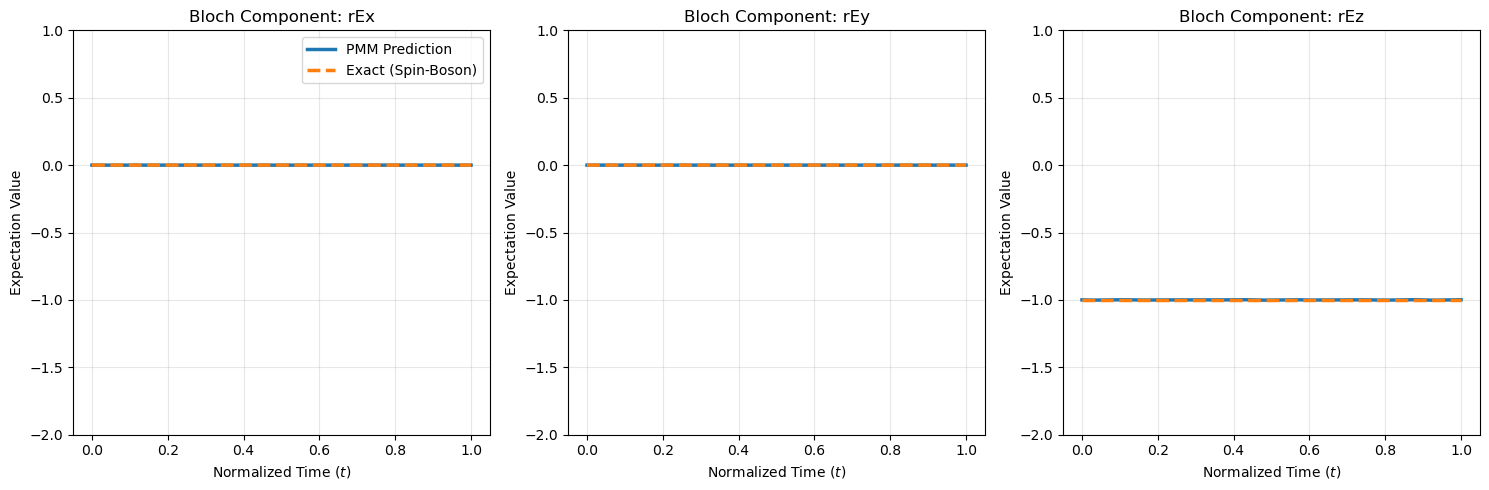

In [7]:
import matplotlib.pyplot as plt

# 1. Generate Predictions
y_pred = Model.predict(New_theta, X_test)
labels = ['rEx', 'rEy', 'rEz']
targets = [y_rEx, y_rEy, y_rEz]

# 2. Setup Figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# 3. Plot Components
for i, ax in enumerate(axes):
    # Plot Prediction vs Exact Data
    ax.plot(t_scaled, y_pred[:, i], label='PMM Prediction', lw=2.5, color='tab:blue')
    ax.plot(t_scaled, targets[i],   label='Exact (Spin-Boson)', lw=2.5, ls='--', color='tab:orange')

    # Formatting
    ax.set_title(f'Bloch Component: {labels[i]}')
    ax.set_xlabel('Normalized Time ($t$)')
    ax.set_ylabel('Expectation Value')
    ax.set_ylim(-2,1)
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend()

plt.tight_layout()
plt.show()

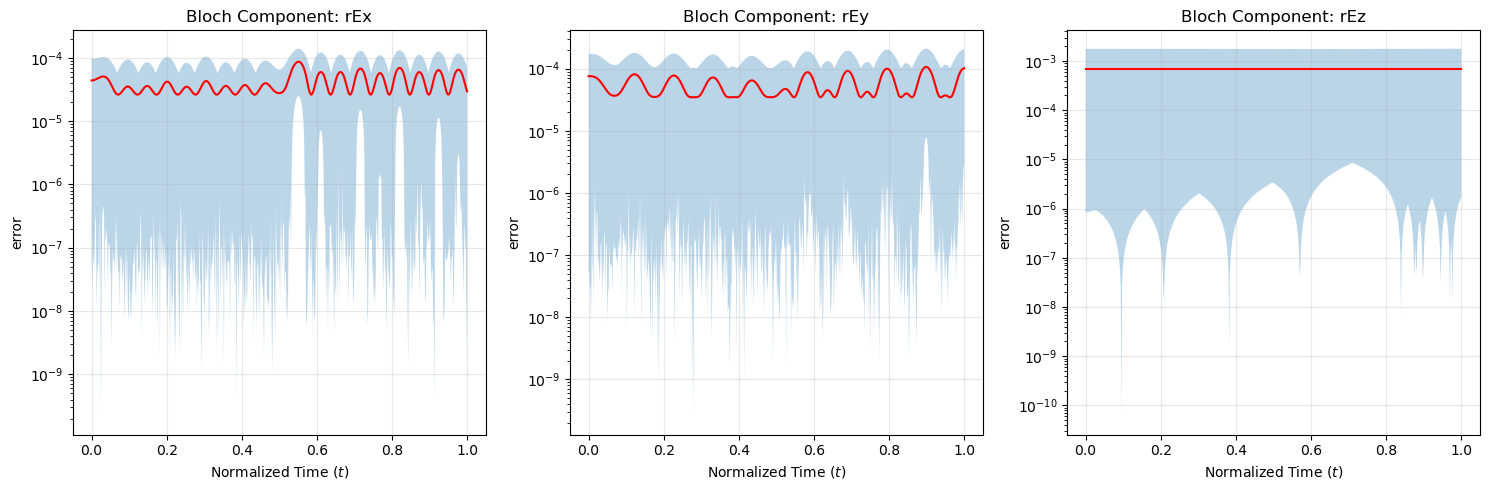

In [8]:
#plot abs

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
labels = ['rEx', 'rEy', 'rEz']
targets = [y_rEx, y_rEy, y_rEz]
# 3. Plot Components
for i, ax in enumerate(axes):
    #abs = np.abs(y_pred[:, i]-targets[i])
    error_all = np.abs(y_pred[..., i] - targets[i])
    max_err = np.max(error_all, axis=1)
    min_err = np.min(error_all, axis=1)

    ax.fill_between(t_scaled, min_err, max_err, alpha=0.3)
    ax.plot(t_scaled, np.mean(error_all, axis=1), color='red')
    ax.set_yscale('log')
    #ax.plot(t_scaled, abs, label='PMM Prediction', lw=2.5)

    # Formatting
    ax.set_title(f'Bloch Component: {labels[i]}')
    ax.set_xlabel('Normalized Time ($t$)')
    ax.set_ylabel('error')
    ax.grid(True, alpha=0.3)
    #if i == 0: ax.legend()

plt.tight_layout()
plt.show()